# PART3_Sup_other_crops

Check prediction accuracy of 5-fold CV using public NAM dataset of maize, soybean, sorghum

In [22]:
import ast
import gzip
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from multiprocessing import Pool
from tqdm import tqdm
from glob import glob

%matplotlib inline
%config InlineBackend.figure_formats = {'png', 'retina'}

from modules.make_data_for_prediction import make_data, make_data_for_Tuning
from modules.tuning import tuning_LightGBM, tuning_Lasso, tuning_ElasticNet
from modules.train_for_accuracy import train_GBLUP, GBLUP_coef, train_lightgbm, train_Lasso, train_Enet

# basic variables
CV=5
optuna_seed=1024

## Parameter tuning & Train model

In [ ]:
def tuning_Enet_multi(inputs):
    params = tuning_ElasticNet(inputs[1], inputs[2], inputs[3])
    return [inputs[0], params]

for sp in ["Maize", "Soybean", "Sorghum"]
    
    # get trait names
    if sp == "Maize":
        trait_names = ['DaysToTassel', 'CobDiameter', 'CobWeight', 'EarDiameter', 'EarRowNumber', 'EarWeight', 'LeafLength', 'LeafWidth', 'PlantHeight'] 
    elif sp == "Soybean":
        trait_names = ['Fiber', 'Ht (in)', 'Lod', 'Mat', 'Oil', 'Protein', 'Yld (bu_a)']
    elif sp="Sorghum":
        trait_names = ['FT', 'PH']

    family_list = pd.read_csv(f"../data/PART3Sup_other_crops/{sp}/family_list.csv")
    family = family_list.family.unique()
    genotype = f"../data/PART3Sup_other_crops/{sp}/{sp}_LD90.csv.gz"
    phenotype = f"../data/PART3Sup_other_crops/{sp}/phenotype_for_analysis.csv"
    
    # tuning parameters of Elastic Net
    for trait_name in trait_names:
        print(trait_name)
        test_data, train_data, position_data = make_data(family, family_list, trait_name, genotype, phenotype, CV, seed=1024)

        p = Pool(CV)
        inputs_list = [[i, train_data[i][0], train_data[i][1], family_list] for i in range(CV)]
        results = p.map(tuning_Enet_multi, inputs_list)
        Enet_params = [[trait_name, result[0], result[1]] for result in results]
        p.close()
        pd.DataFrame(Enet_params).to_csv("../data/PART3Sup_other_crops/params/{}_Enet_all_{}_params.csv".format(sp, trait_name))


def train_Enet_multi(inputs):
    test_pred, r2, acc_RIL, coefs = train_Enet(inputs[1], inputs[2], inputs[3], inputs[4])
    return [inputs[0], test_pred, r2, acc_RIL, coefs]

for sp in ["Maize", "Soybean", "Sorghum"]
    
    # get trait names
    if sp == "Maize":
        trait_names = ['DaysToTassel', 'CobDiameter', 'CobWeight', 'EarDiameter', 'EarRowNumber', 'EarWeight', 'LeafLength', 'LeafWidth', 'PlantHeight'] 
    elif sp == "Soybean":
        trait_names = ['Fiber', 'Ht (in)', 'Lod', 'Mat', 'Oil', 'Protein', 'Yld (bu_a)']
    elif sp="Sorghum":
        trait_names = ['FT', 'PH']
    
    family_list = pd.read_csv(f"../data/PART3Sup_other_crops/{sp}/family_list.csv")
    family = family_list.family.unique()
    genotype = f"../data/PART3Sup_other_crops/{sp}/{sp}_LD90.csv.gz"
    phenotype = f"../data/PART3Sup_other_crops/{sp}/phenotype_for_analysis.csv"
    
    # train models
    for trait_name in trait_names:
        summary = []
        print(trait_name)
        # separate test & train dataset
        test_data, train_data, position_data = make_data(family, family_list, trait_name, genotype, phenotype, CV, seed=1024, plot=False)

        inputs_list = []
        for i in range(CV):
            params = pd.read_csv("../data/PART3Sup_other_crops/params/{}_Enet_all_{}_params.csv".format(sp, trait_name), index_col=0)
            params.columns = ["trait", "CV", "params"]
            params = ast.literal_eval(params.loc[(params["trait"] == trait_name) & (params["CV"] == i), "params"].values[0])
            inputs_list.append([i, test_data[i], train_data[i], params, family_list, model])

        p = Pool(CV)
        results = p.map(train_Enet_multi, inputs_list)
        p.close()
        results = [[trait_name, "Enet", tmp[0], tmp[1], tmp[2], tmp[3], tmp[4]] for tmp in results]
        summary.extend(results)

    with gzip.open(f'../data/PART3Sup_other_crops/{sp}_Enet_by_all_RILs_HBs.pic.bin.gz', 'wb') as p:
        pickle.dump(summary, p)


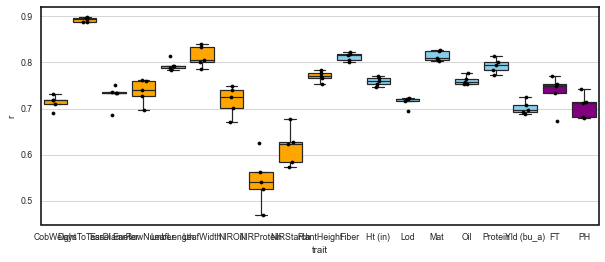

In [8]:
# visualize prediction accuracy

# get prediction results
box_data = pd.DataFrame()
for sp in ["Maize", "Soybean", "Sorghum"]:
    with gzip.open(f'../data/PART3Sup_other_crops/{sp}_Enet_by_all_RILs_HBs.pic.bin.gz', 'rb') as p:
        summary = pickle.load(p)
    summary = pd.DataFrame(summary)
    for i in summary.iloc[:, 0].unique():
        trait_summary = summary[summary.iloc[:, 0] == i]
        box_data = pd.concat([box_data, trait_summary.iloc[:, [0,4]]])
box_data.columns = ["trait", "r"]

# set colors
colors = list(np.repeat("orange", 10))
colors.extend(np.repeat("skyblue", 7))
colors.extend(np.repeat("purple", 2))

# visualize box plots
sns.set('paper', 'whitegrid')
plt.figure(figsize=(10, 4))
ax = sns.boxplot(data=box_data, x="trait", y="r", palette=colors, saturation=1, sym="")
sns.stripplot(data=box_data, x="trait", y="r", dodge=True, edgecolor="black", linewidth=.75, color="black", size=3, ax=ax)
for sp in ["top", "left", "right", "bottom"]:
    ax.spines[sp].set_color('black')
    ax.spines[sp].set_linewidth(1.5)
plt.show()

In [16]:
# get the average preiction accuracy from CV1-5
for sp in ["Maize", "Soybean", "Sorghum"]:
    print(sp)
    with gzip.open(f'../data/PART3Sup_other_crops/{sp}_Enet_by_all_RILs_HBs.pic.bin.gz', 'rb') as p:
        summary = pickle.load(p)
    summary = pd.DataFrame(summary)
    display(summary.iloc[:, [0,1,4]].groupby([0]).mean())

Maize


,4
0,
CobWeight,0.713901
DaysToTassel,0.893200
EarDiameter,0.727864
EarRowNumber,0.737472
LeafLength,0.794213
LeafWidth,0.813196
NIROil,0.717632
NIRProtein,0.544202
NIRStarch,0.616394


Soybean


,4
0,
Fiber,0.812751
Ht (in),0.758982
Lod,0.714822
Mat,0.814043
Oil,0.760858
Protein,0.792855
Yld (bu_a),0.701864


Sorghum


,4
0,
FT,0.735985
PH,0.705832
